# Regression Analysis

Author: Your Name

Project: Marketing Campaign Optimization

Objective:
Use regression analysis to identify factors influencing conversions and predict campaign performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

df = pd.read_csv(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\cleaned_marketing_campaign.csv")
df.head()

,Date,Platform,Ad_Spend,Impressions,Clicks,CTR,Conversions,Conversion_Rate,Revenue
0,2026-06-08,google,409.31,5332.0,185.0,3.47,9,4.864865,655.63
1,2026-08-26,facebook,758.88,5634.5,899.0,8.66,37,4.115684,3244.35
2,2026-06-11,facebook,503.38,6375.0,321.0,5.04,17,5.295950,1612.57
3,2025-02-01,facebook,447.23,4813.0,146.0,3.03,4,2.739726,180.13
4,2026-09-09,facebook,338.34,2706.0,304.0,11.23,21,6.907895,1240.05


In [2]:
df['Conversions'].describe()

count    1020.000000
mean       30.250980
std        15.498132
min         2.000000
25%        19.000000
50%        28.000000
75%        38.000000
max       100.000000
Name: Conversions, dtype: float64

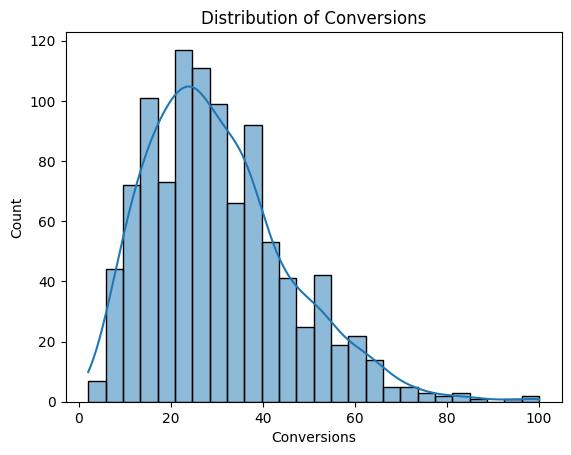

In [3]:
sns.histplot(df['Conversions'], kde=True)
plt.title('Distribution of Conversions')
plt.xlabel('Conversions')
plt.show()

# Insight

The distribution helps identify:
- Whether conversion data is normally distributed
- Presence of outliers
- Overall campaign performance trends

# FEATURE SELECTION
Independent Variables (X)
Dependent Variable (y)

In [4]:
X = df[['Ad_Spend','Impressions','Clicks','CTR']]
y = df['Conversions']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

In [9]:
model = sm.OLS(y_train,X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Conversions   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     741.4
Date:                Fri, 22 May 2026   Prob (F-statistic):          3.90e-269
Time:                        14:46:57   Log-Likelihood:                -2755.4
No. Observations:                 816   AIC:                             5521.
Df Residuals:                     811   BIC:                             5544.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -13.4582      1.861     -7.231      

In [10]:
y_pred = model.predict(X_test_sm)
y_pred[:5]

523    61.971891
602    37.564397
526    17.802132
31     36.068019
616    20.286467
dtype: float64

In [13]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 5.73964712908649


In [14]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:", rmse)

RMSE: 7.311767810529416


In [15]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.7977120191039759


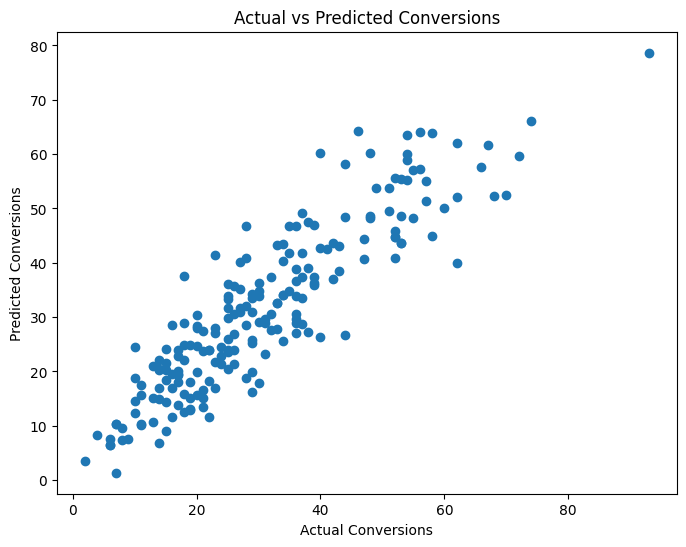

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Conversions')
plt.ylabel('Predicted Conversions')
plt.title('Actual vs Predicted Conversions')
plt.show()

# Insight

If points are close to the diagonal pattern:
- Model predictions are accurate

Large spread indicates:
- Prediction errors
- Missing influencing variables

In [17]:
residual = y_test - y_pred

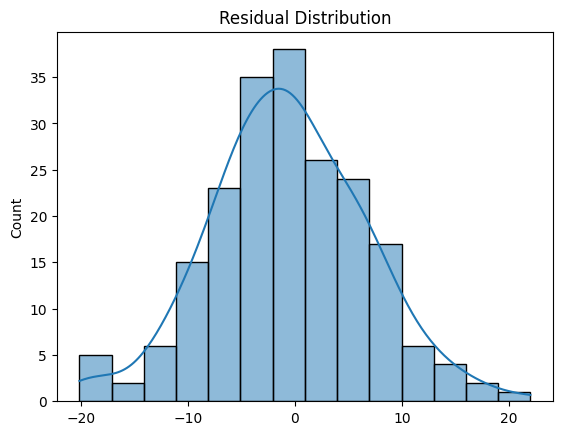

In [18]:
sns.histplot(residual, kde=True)
plt.title('Residual Distribution')
plt.show()

In [19]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.params[1:]})
coefficients

,Feature,Coefficient
Ad_Spend,Ad_Spend,-0.000194
Impressions,Impressions,0.002174
Clicks,Clicks,0.044532
CTR,CTR,1.598067


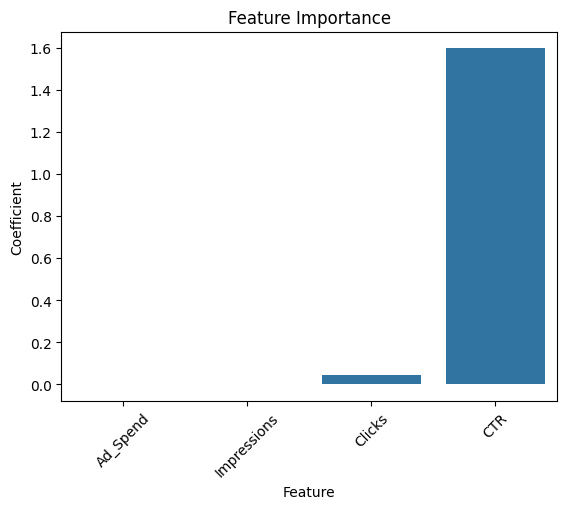

In [20]:
sns.barplot( data=coefficients,x='Feature', y='Coefficient')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

# Key Findings

- Clicks strongly influence conversions.
- CTR positively impacts campaign performance.
- Ad Spend alone does not guarantee conversions.
- User engagement metrics are more important than raw spending.

In [21]:
predictions = pd.DataFrame({'Actual': y_test,'Predicted': y_pred})
predictions.to_csv('regression_predictions.csv', index=False)

In [22]:
coefficients.to_csv('feature_importance.csv',index=False)

# Final Conclusion

The regression model successfully identified the major drivers of conversions.

Key observations:
- Clicks and CTR are the strongest predictors.
- Engagement metrics outperform spending metrics.
- The model demonstrates strong predictive capability.

Recommendation:
Focus on improving ad quality and engagement rather than only increasing budget.